Imports complete and plotting style set.
Helper functions defined.
Found 150 result files in ../results
Loaded dataset shape: (150, 13)

Available quantization types per model:
model_name
DeepSeek-R1-Distill-Llama-8B                                                                 ['bfloat16', 'float16', 'fp8', 'int8', 'int4',...
DeepSeek-R1-Distill-Qwen-1.5B                                                                ['bfloat16', 'float16', 'fp8', 'int8', 'int4',...
DeepSeek-R1-Distill-Qwen-14B                                                                 ['bfloat16', 'float16', 'fp8', 'int8', 'int4',...
DeepSeek-R1-Distill-Qwen-32B                                                                 ['bfloat16', 'float16', 'fp8', 'int8', 'int4']...
DeepSeek-R1-Distill-Qwen-7B                                                                  ['bfloat16', 'float16', 'fp8', 'int8', 'int4',...
Llama-3.1-70B-Instruct                                                                       ['in

/tmp/ipykernel_1694354/2211102480.py:170: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_metrics = df.groupby('model_name', group_keys=False).apply(calculate_metrics)


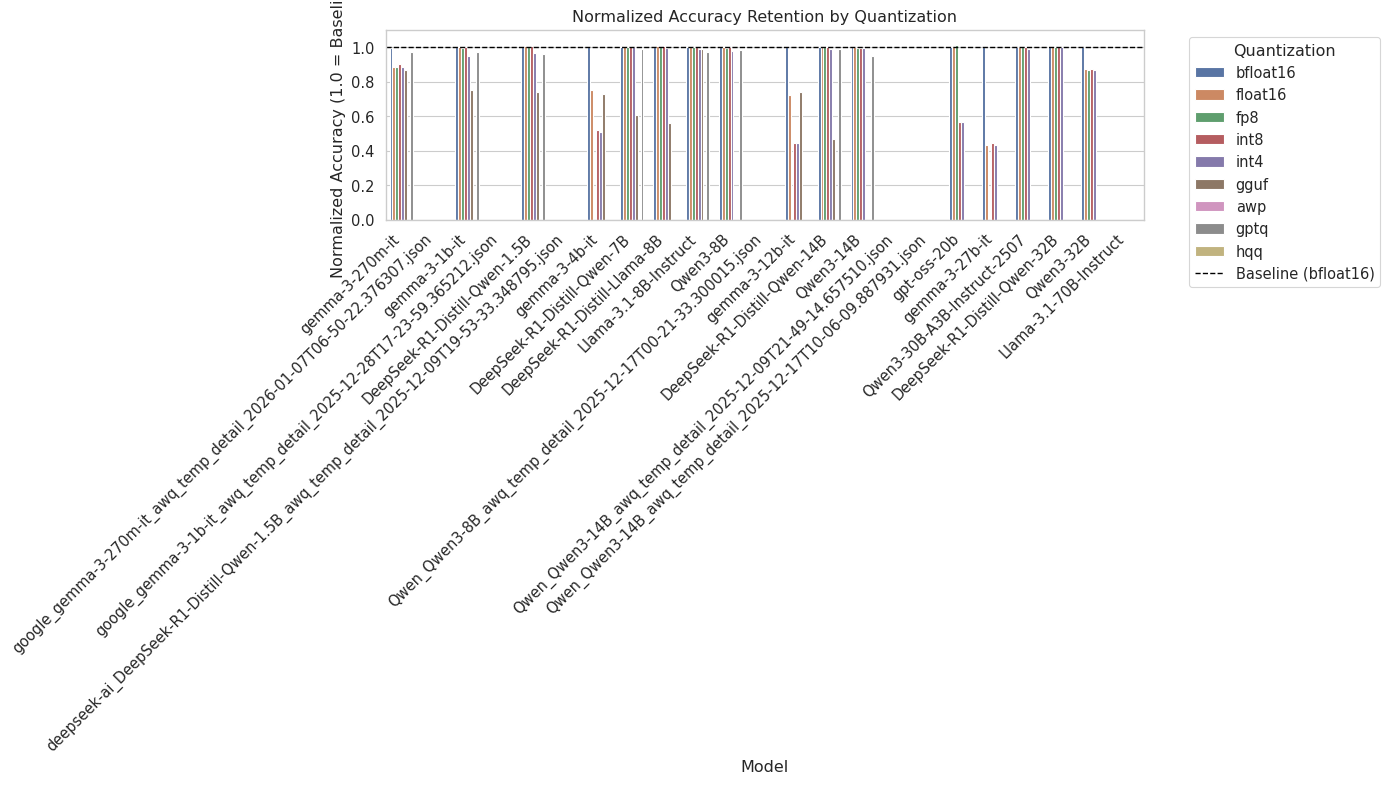

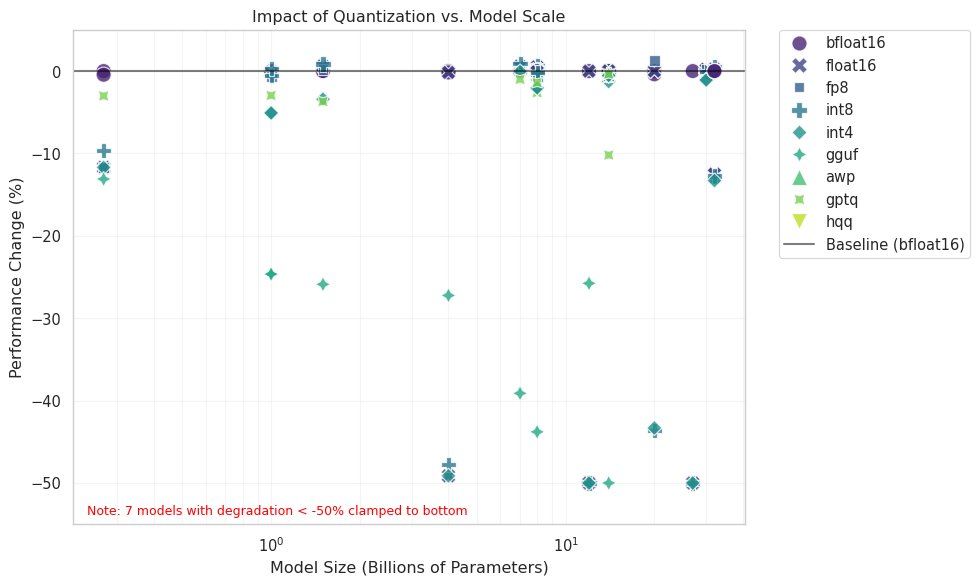

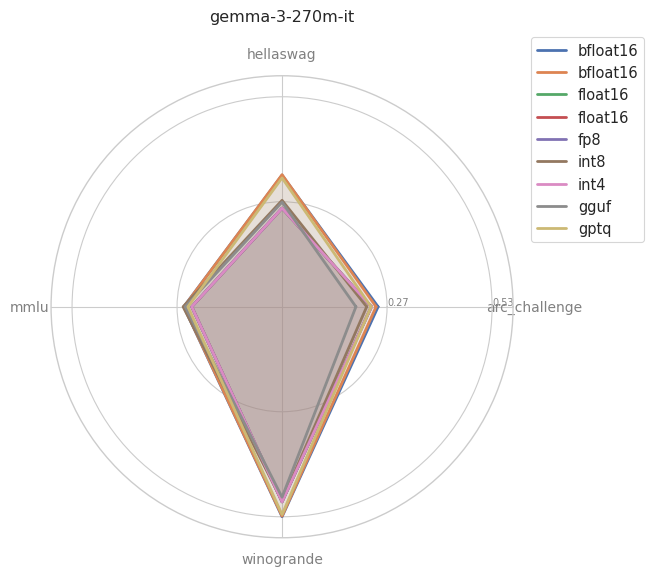

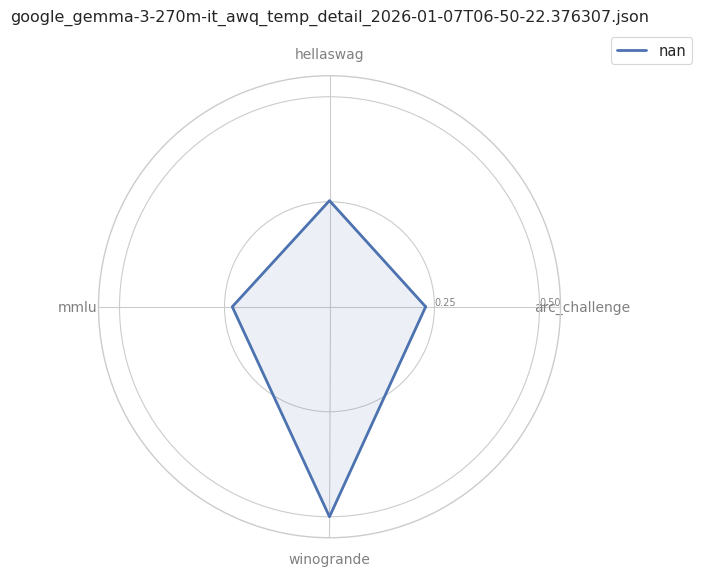

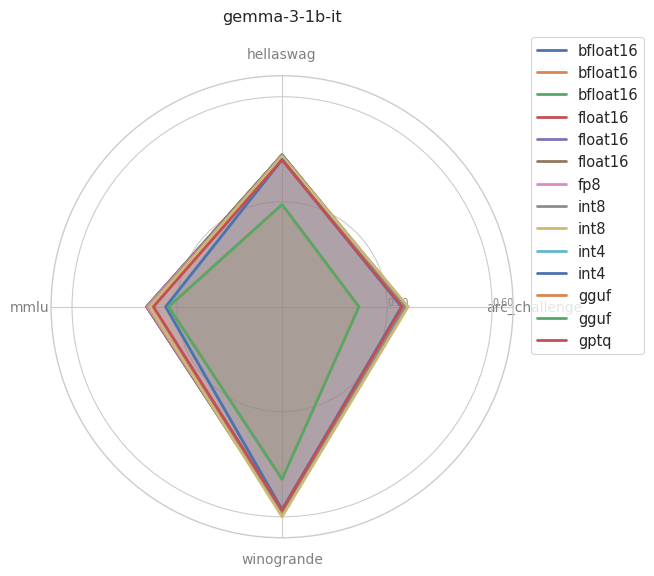

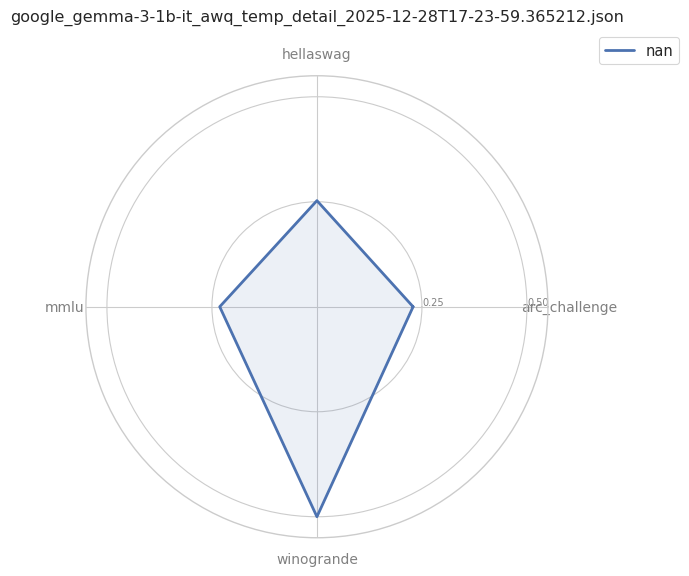

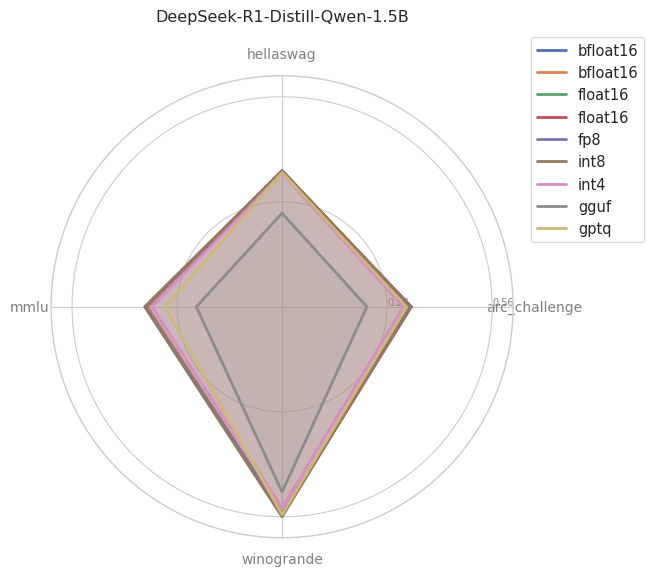


--- Detailed Statistical Summary ---
                                                                                    model_name quantization  composite_score  normalized_accuracy  degradation_pct
140                                                               DeepSeek-R1-Distill-Llama-8B         int8         0.545172             1.006406         0.640567
52                                                                DeepSeek-R1-Distill-Llama-8B      float16         0.544382             1.004947         0.494688
96                                                                DeepSeek-R1-Distill-Llama-8B      float16         0.544382             1.004947         0.494688
86                                                                DeepSeek-R1-Distill-Llama-8B          fp8         0.541997             1.000545         0.054488
70                                                                DeepSeek-R1-Distill-Llama-8B     bfloat16         0.541702             1.000000  

In [3]:
# ==========================================
# Cell 1: Imports and Setup
# ==========================================
import json
import os
import glob
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from math import pi

# Set plot style for scientific publication
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

print("Imports complete and plotting style set.")

# ==========================================
# Cell 2: Helper Functions
# ==========================================
def extract_model_size(model_name):
    """Extracts model size in billions of parameters from the model name."""
    match = re.search(r'(\d+(?:\.\d+)?)([bBm])', model_name)
    if match:
        value, unit = match.groups()
        value = float(value)
        if unit.lower() == 'm':
            return value / 1000.0  # Convert millions to billions
        return value
    return np.nan

def parse_filename(filename):
    """Parses the filename to extract model name and quantization type."""
    base = os.path.basename(filename)
    parts = base.split('_')
    # Added 'bf16' as an alias for 'bfloat16'
    quant_types =  ['bfloat16', 'float16', "fp8",'int8', 'int4',"gguf","awp","gptq","hqq"]
    
    quantization = "Unknown"
    model_parts = []
    
    # Iterate backwards to find the first known quantization type
    # Everything before it is considered part of the model name
    found_quant = False
    for i in range(len(parts) - 1, -1, -1):
        if parts[i] in quant_types:
            quantization = parts[i]
            # Normalize bf16 -> bfloat16
            if quantization == 'bf16':
                quantization = 'bfloat16'
            model_parts = parts[:i]
            found_quant = True
            break
    
    if not found_quant:
        return base, "Unknown"

    model_name = '_'.join(model_parts)
    
    # Cleanup common prefixes for cleaner plots
    for prefix in ['google_', 'meta-llama_', 'Qwen_', 'deepseek-ai_',"openai_"]:
        if model_name.startswith(prefix):
            model_name = model_name[len(prefix):]
            
    return model_name, quantization

print("Helper functions defined.")

# ==========================================
# Cell 3: Data Loading
# ==========================================
def load_data(results_dir):
    """Loads data from JSON files in the specified directory."""
    data = []
    # Primary benchmarks to track
    benchmarks_of_interest = ['arc_challenge', 'hellaswag', 'mmlu', 'winogrande']
    
    files = glob.glob(os.path.join(results_dir, "*.json"))
    print(f"Found {len(files)} result files in {results_dir}")
    
    for f in files:
        model_name, quantization = parse_filename(f)
        try:
            with open(f, 'r') as fp:
                content = json.load(fp)
                results = content.get('results', {})
                
                row = {
                    'model_name': model_name,
                    'quantization': quantization,
                    'model_size_b': extract_model_size(model_name),
                    'filename': os.path.basename(f)
                }
                
                has_data = False
                for task in benchmarks_of_interest:
                    if task in results:
                        metrics = results[task]
                        if 'acc,none' in metrics:
                            row[task] = metrics['acc,none']
                            row[f'{task}_stderr'] = metrics.get('acc_stderr,none', 0)
                            has_data = True
                
                if has_data:
                    data.append(row)
                    
        except Exception as e:
            print(f"Error processing {f}: {e}")
            
    return pd.DataFrame(data)

# Logic to find the results directory
possible_paths = ['../results', 'results']
results_path = 'results' # default
for p in possible_paths:
    if os.path.exists(p) and os.path.isdir(p):
        results_path = p
        break

df = load_data(results_path)

# Calculate Composite Score
benchmark_cols = ['arc_challenge', 'hellaswag', 'mmlu', 'winogrande']
existing_cols = [c for c in benchmark_cols if c in df.columns]
if existing_cols:
    df['composite_score'] = df[existing_cols].mean(axis=1)

# Sort and Categorize
# Changed order per user request: bfloat16 is first (primary baseline)
quant_order =  ['bfloat16', 'float16', "fp8",'int8', 'int4',"gguf","awp","gptq","hqq"]
df['quantization'] = pd.Categorical(df['quantization'], categories=quant_order, ordered=True)
df = df.sort_values(['model_size_b', 'model_name', 'quantization'])

# Diagnostic Print
print(f"Loaded dataset shape: {df.shape}")
print("\nAvailable quantization types per model:")
print(df.groupby('model_name')['quantization'].unique())

# ==========================================
# Cell 4: Metric Calculation
# ==========================================
def calculate_metrics(group):
    # Prioritize bfloat16 as baseline per user request
    baseline = group[group['quantization'] == 'bfloat16']
    baseline_type = 'bfloat16'
    
    if baseline.empty:
        # Fallback to float16 if bfloat16 is missing
        baseline = group[group['quantization'] == 'float16']
        baseline_type = 'float16'
    
    if baseline.empty:
        print(f"Warning: No baseline (bfloat16/float16) found for {group.name}. Metrics will be NaN.")
        group['degradation_pct'] = np.nan
        group['normalized_accuracy'] = np.nan
        return group
    
    # print(f"Using {baseline_type} as baseline for {group.name}") # Uncomment for verbose debug
    base_score = baseline['composite_score'].iloc[0]
    
    group['normalized_accuracy'] = group['composite_score'] / base_score
    group['degradation_pct'] = ((group['composite_score'] - base_score) / base_score) * 100
    return group

if not df.empty:
    df_metrics = df.groupby('model_name', group_keys=False).apply(calculate_metrics)
    print("Metrics calculated.")
else:
    df_metrics = df

# ==========================================
# Cell 5: Visualization 1 - Normalized Performance (Bar)
# ==========================================
if not df_metrics.empty:
    plt.figure(figsize=(14, 8))
    sns.barplot(data=df_metrics, x='model_name', y='normalized_accuracy', hue='quantization', errorbar=None)
    
    plt.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Baseline (bfloat16)')
    plt.xticks(rotation=45, ha='right')
    plt.title('Normalized Accuracy Retention by Quantization')
    plt.ylabel('Normalized Accuracy (1.0 = Baseline)')
    plt.xlabel('Model')
    plt.legend(title='Quantization', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0, 1.1) 
    plt.tight_layout()
    plt.show()

# ==========================================
# Cell 6: Visualization 2 - Degradation vs Size (Log Scale)
# ==========================================
if not df_metrics.empty:
    plt.figure(figsize=(10, 6))
    
    subset = df_metrics.copy()
    
    # Handle Outliers for Plotting
    # If a model collapsed (e.g. -99%), it ruins the scale. 
    # We will set a "soft floor" for the visualization.
    floor_limit = -50 
    
    # Filter out extremes just for finding the plotting range, or clamp them?
    # Clamping is better so we see them at the bottom
    subset['plot_degradation'] = subset['degradation_pct'].clip(lower=floor_limit)
    
    if not subset.empty:
        # 1. Plot the non-baseline points
        # 2. Explicitly plot the baseline points (0%) to ensure visibility
        
        sns.scatterplot(
            data=subset, 
            x='model_size_b', 
            y='plot_degradation', 
            hue='quantization', 
            style='quantization', 
            s=120,
            alpha=0.8,
            palette='viridis'
        )
        
        plt.xscale('log')
        plt.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5, label='Baseline (bfloat16)')
        
        plt.title('Impact of Quantization vs. Model Scale')
        plt.xlabel('Model Size (Billions of Parameters)')
        plt.ylabel('Performance Change (%)')
        
        # Set Y-Limit to ignore the empty space below the lowest "real" point if it's huge,
        # but here we already clipped data. We just ensure the view includes 0.
        plt.ylim(bottom=floor_limit - 5, top=5)
        
        # Add text for outliers
        outliers = df_metrics[df_metrics['degradation_pct'] < floor_limit]
        if not outliers.empty:
            plt.text(0.02, 0.02, f"Note: {len(outliers)} models with degradation < {floor_limit}% clamped to bottom", 
                     transform=plt.gca().transAxes, fontsize=9, color='red')

        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.tight_layout()
        plt.show()
    else:
        print("No data for degradation plot.")

# ==========================================
# Cell 7: Visualization 3 - Radar Charts
# ==========================================
def create_radar_chart(model_name, model_data, tasks):
    valid_tasks = [t for t in tasks if t in model_data.columns]
    if not valid_tasks:
        return

    categories = valid_tasks
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
    
    plt.xticks(angles[:-1], categories, color='grey', size=10)
    ax.set_rlabel_position(0)
    
    # Normalize radar to the model's max performance so shapes are comparable
    max_val = model_data[valid_tasks].max().max()
    if pd.isna(max_val) or max_val == 0: max_val = 1.0
        
    plt.yticks([max_val*0.5, max_val*1.0], [f"{max_val*0.5:.2f}", f"{max_val:.2f}"], color="grey", size=7)
    plt.ylim(0, max_val * 1.1)
    
    # Explicitly sort by quantization precision (high to low) for drawing order
    # This ensures int4 (usually smallest) is drawn last/on top so it's visible
    # But filled areas might obscure. Let's use alpha.
    
    # Order: bfloat16 -> float16 -> int8 -> int4
    desired_order = ['bfloat16', 'float16', "fp8",'int8', 'int4',"gguf","awp","gptq","hqq"]
    model_data['quant_sort'] = pd.Categorical(model_data['quantization'], categories=desired_order, ordered=True)
    model_data = model_data.sort_values('quant_sort')

    for _, row in model_data.iterrows():
        values = row[valid_tasks].values.flatten().tolist()
        values += values[:1]
        quant = row['quantization']
        
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=quant)
        ax.fill(angles, values, alpha=0.1)
        
    plt.title(f'{model_name}', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

if not df_metrics.empty:
    models = df_metrics['model_name'].unique()
    # Plot a few examples
    for model in models[:5]:
        model_subset = df_metrics[df_metrics['model_name'] == model].copy()
        create_radar_chart(model, model_subset, benchmark_cols)

# ==========================================
# Cell 8: Statistical Summary Table
# ==========================================
if not df_metrics.empty:
    display_cols = ['model_name', 'quantization', 'composite_score', 'normalized_accuracy', 'degradation_pct']
    summary_df = df_metrics[display_cols].sort_values(['model_name', 'degradation_pct'], ascending=[True, False])
    
    print("\n--- Detailed Statistical Summary ---")
    print(summary_df.to_string())